[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/StructuralRL/SRL/blob/main/tutorials/03_household_moving_prices.ipynb)

**Running on Colab?** Just run the setup cell below. It clones the repo and installs the package. For a free GPU: Runtime → Change runtime type → GPU.

In [1]:
# --- Colab setup (auto-injected by build_notebooks.py; do not edit the .ipynb) ---
import os, sys, subprocess

if "google.colab" in sys.modules and os.path.basename(os.getcwd()) != "tutorials":
    # Clone the repo (this also brings calibration.py and the data/ reference
    # files the notebooks load) and install the package.
    if not os.path.isdir("SRL"):
        url = "https://github.com/StructuralRL/SRL.git"
        subprocess.run(["git", "clone", "--depth=1", url, "SRL"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", "SRL"], check=True)
    # --no-deps: Colab already ships jax (with its matched GPU plugin), optax,
    # numpy, scipy, matplotlib, and tqdm. Installing our pinned jax here would
    # desync it from the preinstalled GPU plugin and crash GPU runtimes.
    # Import srl straight from the clone. A mid-session `pip install -e`
    # registers the package only through a .pth file that Python reads at
    # startup, so it does not take effect in the already-running Colab
    # kernel. Putting the repo root on sys.path makes `import srl` work now.
    sys.path.insert(0, os.path.abspath("SRL"))
    os.chdir("SRL/tutorials")
    sys.path.insert(0, os.getcwd())

# 3. The household with moving prices

In notebooks 0–2 the bond price `q` was a fixed scalar. We solved that one
fixed-price household problem three ways (VFI in NumPy, VFI in JAX, and the
structural policy gradient), and all three agreed. This notebook switches on
**one new moving piece: the price moves.** The household now faces an *exogenous*
process for the bond price `q` and for aggregate productivity `z`, and must
choose consumption as a function of the macro state it happens to be in.

This is a small change to the model and almost no change to the code, but it
is the conceptual hinge of the whole course, for two reasons.

- **It is where the policy gradient's simulation finally does real work.** In
  notebook 2 the price was fixed and there was no aggregate shock, so the
  expectation defining lifetime utility was trivial: "nothing left to
  sample," as we said there. Now the `(q, z)` path is exactly the thing the
  solver simulates, while the household's *own* dynamics are still
  differentiated exactly. The structural partition from notebook 2 now does
  something concrete.
- **It is the rehearsal for general equilibrium.** In SRL the household always
  treats prices as a *given process* it conditions on, even in equilibrium.
  Notebook 4 will change exactly one thing: the price process becomes
  *endogenous*, generated by market clearing instead of handed down
  exogenously. By isolating "condition on a moving price" here, with the price
  still exogenous, we get to meet that idea on its own before markets close the
  loop.

## What you should already know

- **Notebook 2**: the Structural Policy Gradient: that lifetime utility is a
  simulated expectation, that the *known* individual dynamics enter through the
  transition matrix $\mathbf{A}_\pi$ and are differentiated exactly, and that
  the expectation is taken *only over what we don't know* (the price and
  aggregate paths). Also the `(state_space, action_space, AUS_func, reset_func)`
  interface to `SPGSolver`.
- **Notebook 1**: `VFISolver`. We use it here, on the bigger state space, as the
  reference the policy gradient must reproduce.

In [2]:
import os

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from calibration import SIGMA, BETA, Q_FIXED, asset_grid, rouwenhorst

jax.config.update("jax_enable_x64", True)   # match notebooks 0–2 to high precision

sigma, gamma = SIGMA, BETA                  # gamma is the discount factor (SPG's name for beta)
eps = 1e-9                                  # consumption floor

## The model: one new moving piece

The household problem is the one you already know, with the budget constraint
carrying two aggregates that now *move*:
$$c + q\,b' = b + z\,y, \qquad b' \ge 0,$$
so wealth is $b + z\,y$ and next assets are $b' = (b + z\,y - c)/q$. Two things
changed from notebook 2, where $q$ was fixed and $z\equiv 1$:

- **$q$, the bond price, is now a state**, following an exogenous Markov
  process. A high $q$ is a low interest rate ($r = 1/q - 1$): saving earns
  little and bonds are expensive.
- **$z$, aggregate productivity, is now a state**, scaling everyone's income
  $z\,y$, also following an exogenous Markov process.

The individual state grows from $(b, y)$ to $(b, y, q, z)$, and the policy
becomes $\text{cshare}(b, y, q, z)$: the consumption share now depends on the
aggregate conditions the household faces. Crucially, the cross-sectional
distribution still lives on the *individual* states $(b, y)$; the aggregates
$(q, z)$ are **exogenous** states carried along the simulated path, not part of
the distribution. (That distinction is exactly what `markov` vs. `non-markov`
encodes in the `state_space` below.)

### The household block: the spine calibration (notebooks 0–4)

The household (risk aversion, discount factor, income process, asset grid) is
the *same economy* as notebooks 0–2, read from the shared `calibration.py`.
Only the new aggregate processes are added here.

In [3]:
n_b = 80                                    # asset-grid points (tutorial scale; paper uses 200)
b_grid = jnp.asarray(asset_grid(n_b))       # non-uniform, dense near b = 0
e_np, Pi_np = rouwenhorst()                 # 3-state income: levels and transition
e_grid, Pi = jnp.asarray(e_np), jnp.asarray(Pi_np)
n_y = e_grid.shape[0]

### The aggregate processes: the new piece

Now the new objects: discretized Markov chains for the two
aggregates. We keep them small and legible.

- **Bond price `q`**: a persistent three-state chain centered on `Q_FIXED =
  0.995`, the very price held fixed in notebooks 0–2. The reader can see the
  whole process: three price levels and the $3\times3$ matrix of transition
  probabilities. (In notebook 4 this exogenous process is *replaced* by one the
  market generates endogenously; here we simply hand the household a plausible
  one.)
- **Aggregate TFP `z`**: a mean-one log-AR(1), discretized with the same
  `rouwenhorst` routine used for income in notebook 0, so productivity
  averages 1 and fluctuates modestly around it.

In [4]:
# Bond price: three levels around 0.995 (r from +1.5% to -0.5%), persistent.
q_grid = jnp.asarray([0.985, Q_FIXED, 1.005])
q_trans = jnp.asarray([[0.80, 0.20, 0.00],
                       [0.10, 0.80, 0.10],
                       [0.00, 0.20, 0.80]])
n_q = q_grid.shape[0]

# Aggregate TFP: mean-one Rouwenhorst chain (same discretization family as income).
z_np, z_trans_np = rouwenhorst(rho=0.9, sigma_y=0.06, n=3)
z_grid, z_trans = jnp.asarray(z_np), jnp.asarray(z_trans_np)
n_z = z_grid.shape[0]

print(f"states: b={n_b}, y={n_y}, q={n_q}, z={n_z}   (distribution lives on b×y = {n_b * n_y})")
print("q levels:", np.asarray(q_grid), " -> r = 1/q - 1:", np.asarray(1 / q_grid - 1).round(4))
print("z levels:", np.asarray(z_grid).round(3), " (mean 1)")

states: b=80, y=3, q=3, z=3   (distribution lives on b×y = 240)
q levels: [0.985 0.995 1.005]  -> r = 1/q - 1: [ 0.0152  0.005  -0.005 ]
z levels: [0.917 0.998 1.087]  (mean 1)


## The structural partition, now with something to simulate

Recall the value vector from notebook 2,
$$\mathbf{v}_\pi=\mathbb{E}\Big[\textstyle\sum_{t\ge 0}\gamma^t\,
  \mathbf{A}_{\pi,0\to t}\,\mathbf{u}_t\Big],$$
where **the expectation is taken only over what we do not know** (the
trajectories of the price $q_t$ and the aggregate shock $z_t$) while the known
individual dynamics are carried *exactly* by the transition matrix
$\mathbf{A}_\pi$ (the income chain $\Pi$ and the interpolated savings rule). In
notebook 2 those unknown trajectories were degenerate: $q$ fixed, no $z$, so
the expectation collapsed and there was nothing to sample.

Here they are live. The policy gradient handles the split mechanically:

- **What we don't know, the aggregate path, is *simulated*.** `reset_func`
  draws an initial $(q, z)$; each step `AUS_func` draws the next $(q, z)$ from
  the Markov transitions. Averaging over many such paths is the expectation
  $\mathbb{E}[\cdot]$ above.
- **What we know, each household's own dynamics, is *differentiated*.** Given
  the simulated $(q, z)$ of the period, the budget constraint and income chain
  still assemble into $\mathbf{A}_\pi$ exactly, and `grad` flows through it
  without any sampling noise.

That is the entire idea of Structural RL, and `AUS_func` below is where it
lives. Compare it line-for-line with notebook 2's: the body is identical except
that (i) it reads $q$ and $z$ from the current state, (ii) wealth is $b + z\,y$,
and (iii) it returns the *next* drawn $(q, z)$ instead of `None`.

In [5]:
from srl.utils.safe_linalg import crra_util_func, interp_two_point_nonuniform


def reset_func(key):
    """Draw an initial aggregate state (q, z): the start of one simulated path."""
    k_q, k_z = jax.random.split(key)
    return jax.random.choice(k_q, n_q), jax.random.choice(k_z, n_z)


def AUS_func(policy, mt, st, key):
    """One-step economics at the current aggregate state st = (q_idx, z_idx).

    Returns (A, U, next_state): the sparse individual-transition A_pi, the
    utility vector U over the (b, y) grid, and the next aggregate state drawn
    from the q and z Markov chains.
    """
    q_idx, z_idx = st
    q, z = q_grid[q_idx], z_grid[z_idx]
    J = n_b * n_y                                     # joint (b, y) states

    def build_row(idx):
        b_idx, y_idx = idx // n_y, idx % n_y
        b, y = b_grid[b_idx], e_grid[y_idx]
        cshare = policy["cshare"][b_idx, y_idx, q_idx, z_idx]   # now indexed by (q, z) too
        wealth = b + z * y                            # income scaled by aggregate TFP z
        c = jnp.clip(wealth * cshare, eps, wealth - eps)
        utility = crra_util_func(c, sigma) * (1.0 - gamma)     # (1-gamma): normalized value
        b_next = (wealth - c) / q                     # next assets at the current price q
        # Place b' on the grid by linear interpolation -> the A_pi transition row.
        lo, hi, w_lo, w_hi = interp_two_point_nonuniform(b_next, b_grid)
        cols = jnp.concatenate([lo * n_y + jnp.arange(n_y, dtype=jnp.int32),
                                hi * n_y + jnp.arange(n_y, dtype=jnp.int32)])
        rows = jnp.full((2 * n_y,), idx, dtype=jnp.int32)
        vals = jnp.concatenate([w_lo * Pi[y_idx], w_hi * Pi[y_idx]])  # x income transition
        return (rows, cols, vals), utility

    A, U = jax.vmap(build_row)(jnp.arange(J, dtype=jnp.int32))
    # Sample the next aggregate state: the "what we don't know" the solver averages over.
    k_q, k_z = jax.random.split(key)
    q_next = jax.random.choice(k_q, n_q, p=q_trans[q_idx])
    z_next = jax.random.choice(k_z, n_z, p=z_trans[z_idx])
    return A, U, (q_next, z_next)


# b, y span the distribution (markov); q, z are exogenous states carried in the path.
state_space = {"b": ("markov", n_b), "y": ("markov", n_y),
               "q": ("non-markov", n_q), "z": ("non-markov", n_z)}
action_space = {"cshare": (0.0001, 1.0, 0.5)}         # (min, max, initial guess = 0.5)

## Solve with the policy gradient

Same solver as notebook 2, same call. We use modest, CPU-friendly settings; the
in-code comment gives the paper-scale values. One setting earns a comment: with
a higher discount factor the simulated paths must run longer before the
discount makes the tail negligible, so `trunc_eps` is loosened a touch to keep
the per-step cost down; the truncated tail is worth far less than the noise
the gradient already carries.

In [6]:
%%time 

from srl import SPGSolver

# Paper-scale: sample_size=32, epoch=400+, trunc_eps=0.001 (run on GPU/Colab),
# which tightens the match below from ~1% to ~0.3% of consumption.
spg = SPGSolver(sample_size=32, epoch=400, warm_up=0, trunc_eps=0.01,
                early_stop=False, seed=0, verbose=False)
spg_policy, logs = spg.solve(gamma, state_space, action_space, AUS_func, reset_func)
print(f"SPG: {len(logs)} epochs, {spg.total_time:.1f}s on this machine")

100%|██████████| 400/400 [00:25<00:00, 15.56it/s, max_l1_err=2.909E-04, time(sec)=25.480, cum(EU)=-0.1007]

SPG: 400 epochs, 25.5s on this machine
CPU times: user 26.7 s, sys: 1.09 s, total: 27.8 s
Wall time: 26.2 s


## The reference: value function iteration on the expanded state

Notebook 2 checked the policy gradient against notebook 0's saved answer.
That answer was for the *fixed*-price problem, so it no longer applies once the
price moves. Instead we recompute the reference here, with `VFISolver` from
notebook 1, on the full $(b, y, q, z)$ state.

Nothing about VFI is new; it is the same Bellman iteration as notebook 1, with
the continuation expectation now taken over the *joint* transition of income,
price, and TFP. We build that joint transition as the (independent) product of
the three chains, $\Pi \otimes q_{\text{trans}} \otimes z_{\text{trans}}$, and
the `transition_func` interpolates the continuation value at $b'$ exactly as
before.

In [7]:
%%time 

from srl import VFISolver

n_action = 4096                                        # consumption-share grid for VFI
c_grid = jnp.linspace(0.0, 1.0, n_action)
# Joint transition over (y, q, z): the three processes are independent.
agg_trans = jnp.einsum("ij,kl,mn->ijklmn", Pi, q_trans, z_trans)


def transition_func(state_indices, a_idx, V):
    """One-step economics for VFISolver: (state, action, V) -> (E[V'], reward)."""
    b_idx, y_idx, q_idx, z_idx = state_indices
    b, y = b_grid[b_idx], e_grid[y_idx]
    q, z = q_grid[q_idx], z_grid[z_idx]
    wealth = b + z * y
    c = jnp.clip(wealth * c_grid[a_idx], eps, wealth - eps)
    b_next = (wealth - c) / q
    i_lo, i_hi, w_lo, w_hi = interp_two_point_nonuniform(b_next, b_grid)
    # E[V(b', y', q', z')]: interpolate V at b', then average over the joint (y',q',z') chain.
    agg_prob = agg_trans[y_idx, :, q_idx, :, z_idx, :]          # (n_y', n_q', n_z')
    nextEV = jnp.sum(V[i_lo] * agg_prob) * w_lo + jnp.sum(V[i_hi] * agg_prob) * w_hi
    return nextEV, crra_util_func(c, sigma)


vfi = VFISolver()
V, vfi_policy, vfi_logs = vfi.solve(
    gamma, {"b": n_b, "y": n_y, "q": n_q, "z": n_z}, n_action, transition_func)
print(f"VFI: {len(vfi_logs)} iterations, {vfi.total_time:.1f}s")

V.shape=(80, 3, 3, 3)


 61%|██████    | 610/1000 [00:07<00:05, 77.98it/s, max_l1_err=9.974E-07, time(sec)=1.435]

VFI: 611 iterations, 1.4s
CPU times: user 3.09 s, sys: 595 ms, total: 3.68 s
Wall time: 8.03 s


## Watch the objective climb

As in notebook 2, gradient ascent raises estimated expected lifetime utility
each step; now the estimate is averaged over simulated *price and TFP* paths,
not just idiosyncratic income.

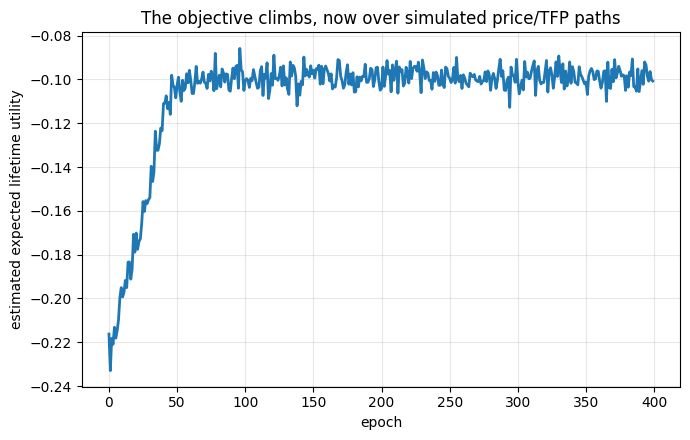

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot([d["cumulative_utility"] for d in logs], lw=2)
ax.set_xlabel("epoch")
ax.set_ylabel("estimated expected lifetime utility")
ax.set_title("The objective climbs, now over simulated price/TFP paths")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## The check: does the policy gradient match VFI as the price moves?

The consumption policy is now a function of four variables, so we slice it: fix
the aggregate TFP state at its middle value and plot $c(b)$ across the three
**price** states, overlaying the policy gradient (dashed) on the VFI reference
(thick, faint) for each income level. If the two methods agree, the dashed
lines sit on the faint ones in every panel.

over b <= 20, across all (q,z):  max |c_SPG - c_VFI| = 3.032e-02, mean = 3.374e-03


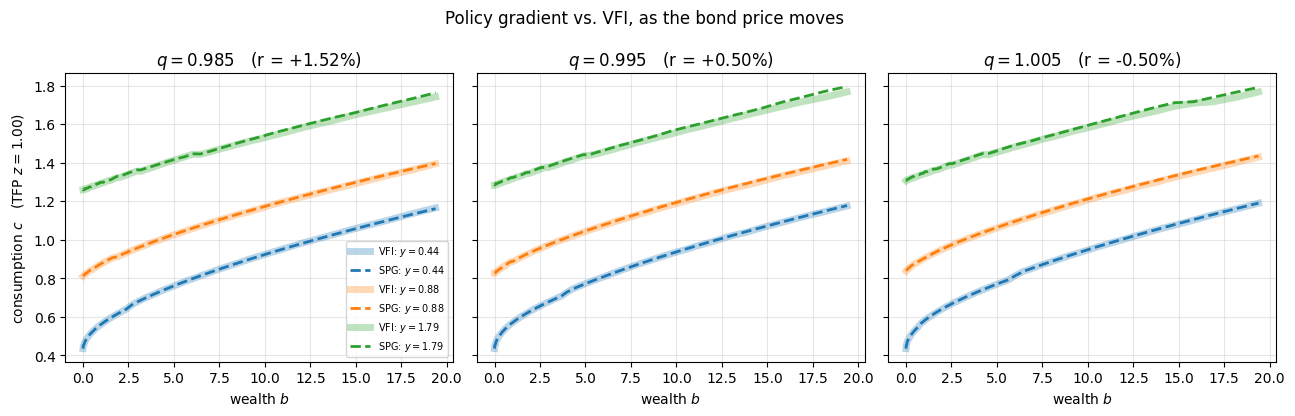

In [9]:
wealth4d = b_grid[:, None, None, None] + z_grid[None, None, None, :] * e_grid[None, :, None, None]
c_spg = np.asarray(jnp.clip(wealth4d * spg_policy["cshare"], eps, wealth4d - eps))
c_vfi = np.asarray(jnp.clip(wealth4d * c_grid[vfi_policy], eps, wealth4d - eps))
b_np = np.asarray(b_grid)
mask = b_np <= 20                                     # the populated region (see note below)

# Quantify the agreement over every (q, z) panel, not just the eye.
diff = np.abs(c_spg[mask] - c_vfi[mask])
print(f"over b <= 20, across all (q,z):  max |c_SPG - c_VFI| = {diff.max():.3e}, "
      f"mean = {diff.mean():.3e}")

z_mid = n_z // 2
fig, axs = plt.subplots(1, n_q, figsize=(13, 4.2), sharex=True, sharey=True)
for j, q_idx in enumerate(range(n_q)):
    ax = axs[j]
    for y_idx in range(n_y):
        line, = ax.plot(b_np[mask], c_vfi[mask, y_idx, q_idx, z_mid], lw=5, alpha=0.3,
                        label=f"VFI: $y={float(e_grid[y_idx]):.2f}$")
        ax.plot(b_np[mask], c_spg[mask, y_idx, q_idx, z_mid], lw=2, ls="--",
                color=line.get_color(), label=f"SPG: $y={float(e_grid[y_idx]):.2f}$")
    ax.set_title(f"$q={float(q_grid[q_idx]):.3f}$   (r = {float(1/q_grid[q_idx]-1):+.2%})")
    ax.set_xlabel("wealth $b$")
    ax.grid(alpha=0.3)
axs[0].set_ylabel(f"consumption $c$   (TFP $z={float(z_grid[z_mid]):.2f}$)")
axs[0].legend(fontsize=7)
fig.suptitle("Policy gradient vs. VFI, as the bond price moves")
plt.tight_layout()
plt.show()

The dashed policy-gradient lines track the VFI reference closely across every
price panel: the printed mean gap is about 1% of consumption at these
CPU-friendly settings, and the paper-scale settings in the comment above bring
it under a third of that. The same honesty from notebook 2 applies, now in four
dimensions: the policy gradient learns *only where households actually go*. Mass
concentrates at low-to-moderate wealth, so the gradient signal is strong there
and the match is tightest; far out in wealth, or in rarely-visited corners of
the $(q, z)$ grid, the signal is thin and the policy stays nearer its initial
guess, which is where the largest gaps sit. Restricting the comparison to the
populated region (`b <= 20`) is the honest comparison, and a reminder that the
method spends its effort where the economy lives.

## What the moving price does to behavior

Now that we trust the solution, read the economics off it. The two new moving pieces act
through two classic channels. We plot the (VFI) policy at a fixed income state,
sweeping one aggregate at a time.

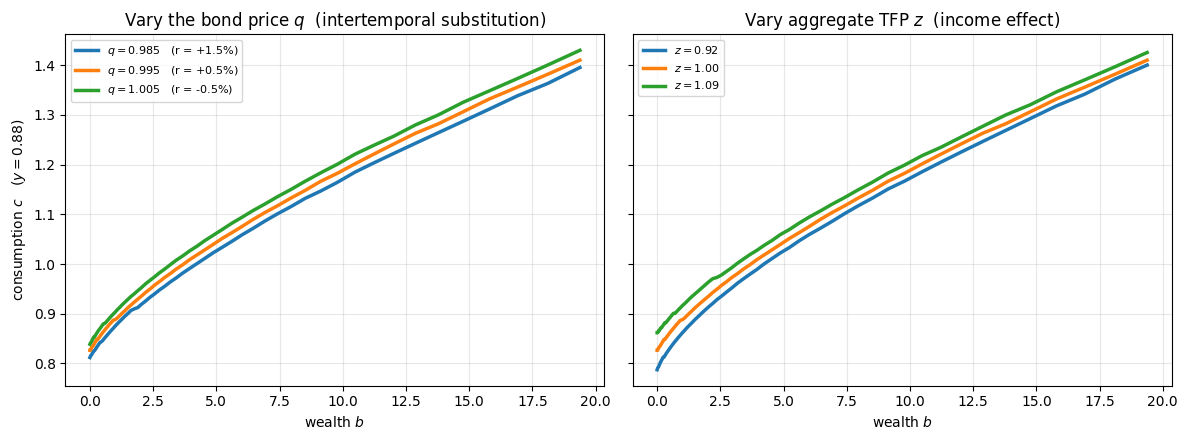

In [10]:
y_mid, q_mid = n_y // 2, n_q // 2
fig, (axq, axz) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# Left: vary the price q (fix z at its middle state).
for q_idx in range(n_q):
    axq.plot(b_np[mask], c_vfi[mask, y_mid, q_idx, z_mid], lw=2.5,
             label=f"$q={float(q_grid[q_idx]):.3f}$   (r = {float(1/q_grid[q_idx]-1):+.1%})")
axq.set_title("Vary the bond price $q$  (intertemporal substitution)")
axq.set_xlabel("wealth $b$")
axq.set_ylabel(f"consumption $c$   ($y={float(e_grid[y_mid]):.2f}$)")
axq.legend(fontsize=8)
axq.grid(alpha=0.3)

# Right: vary aggregate TFP z (fix q at its middle state).
for z_idx in range(n_z):
    axz.plot(b_np[mask], c_vfi[mask, y_mid, q_mid, z_idx], lw=2.5,
             label=f"$z={float(z_grid[z_idx]):.2f}$")
axz.set_title("Vary aggregate TFP $z$  (income effect)")
axz.set_xlabel("wealth $b$")
axz.legend(fontsize=8)
axz.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- **Price (left).** A higher $q$ is a *lower* interest rate. Saving pays less,
  so the household tilts consumption toward the present, consuming more today
  at a given wealth. This is intertemporal substitution, the same force that
  moves the fixed-price policy when you re-solve at a different $q$ (notebook
  1's exercise), except now the household sees $q$ as a *state* and reacts to
  it within one solve.
- **TFP (right).** A higher $z$ scales current income $z\,y$ up, so cash on hand
  and consumption rise across the board. This is the income effect, the seed
  of the aggregate fluctuations notebook 5 will make stochastic.

## Back to notebook 0: the price of anticipation

One more comparison ties the thread back to the start. At the *central*
aggregate state ($q = 0.995$, $z \approx 1$) the household faces almost exactly
the fixed-price economy of notebooks 0–2. So the central-panel policy should
nearly coincide with notebook 0's, but not exactly, because here the household
*knows the aggregate state will move* and saves a little against that. The gap
is small, and it is the household pricing in aggregate risk that the
fixed-price problem cannot see.

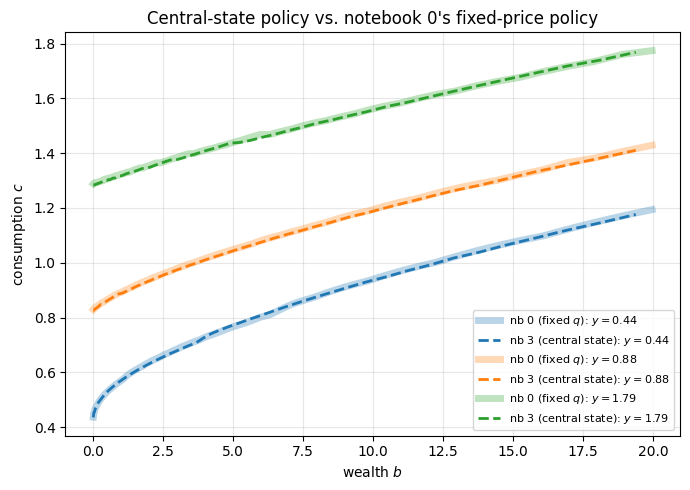

In [11]:
ref0 = np.load(os.path.join(os.path.dirname(__file__) if "__file__" in globals() else ".",
                            "data", "nb0_reference.npz"))
b0, c0 = ref0["b_grid"], ref0["c_policy"]             # notebook 0's grid and fixed-price policy
m0 = b0 <= 20

fig, ax = plt.subplots(figsize=(7, 5))
for y_idx in range(n_y):
    line, = ax.plot(b0[m0], c0[m0, y_idx], lw=5, alpha=0.3,
                    label=f"nb 0 (fixed $q$): $y={float(e_grid[y_idx]):.2f}$")
    ax.plot(b_np[mask], c_vfi[mask, y_idx, q_mid, z_mid], lw=2, ls="--",
            color=line.get_color(), label=f"nb 3 (central state): $y={float(e_grid[y_idx]):.2f}$")
ax.set_xlabel("wealth $b$")
ax.set_ylabel("consumption $c$")
ax.set_title("Central-state policy vs. notebook 0's fixed-price policy")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## What's next

The household now conditions on a *moving* price, but we handed it that price
from outside. **Notebook 4** removes the training wheels: the bond price becomes
**endogenous**, set each period by the condition that the bond market clears.
The household's problem is unchanged: it still takes a price as given, but the
price is now *generated by the economy* rather than assumed. With market
clearing comes the object we have kept in the background until now: the
**wealth distribution**, which aggregates individual saving into market demand.
(Aggregate TFP $z$ is held fixed there, to isolate the
clearing idea; notebook 5 turns it back on, stochastic, for the aggregate-risk
payoff.)

## Exercises

1. **More persistent prices.** Make the bond-price chain stickier (raise the
   diagonal of `q_trans` toward 1). A household that expects today's price to
   last reacts to it more strongly, so the consumption policy should *fan out*
   more across the price panels. Re-solve and compare. Worked below.
2. **Turn the aggregates off.** Collapse both aggregate processes to a single
   state at the center ($q = 0.995$, $z = 1$) and confirm the policy gradient
   collapses back onto notebook 0's fixed-price answer, recovering notebook 2's
   setting as the special case of this one. (Hint: a one-state `non-markov`
   process with transition `[[1.0]]`.)

  0%|          | 0/400 [00:00<?, ?it/s]

100%|██████████| 400/400 [00:24<00:00, 16.57it/s, max_l1_err=3.014E-04, time(sec)=23.770, cum(EU)=-0.0960]


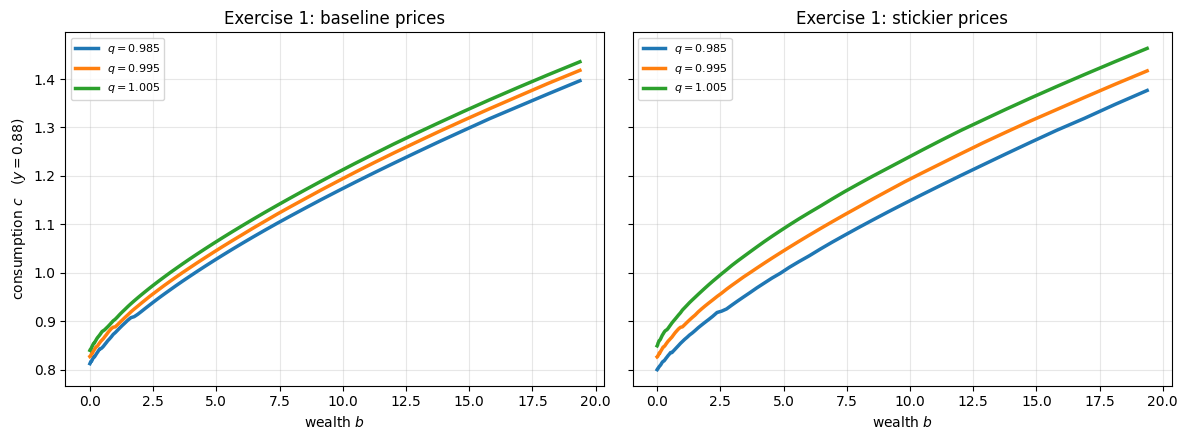

In [13]:
# Exercise 1: stickier price process => stronger conditioning on q.
q_trans_sticky = jnp.asarray([[0.95, 0.05, 0.00],
                              [0.025, 0.95, 0.025],
                              [0.00, 0.05, 0.95]])


def AUS_sticky(policy, mt, st, key):
    q_idx, z_idx = st
    A, U, _ = AUS_func(policy, mt, st, key)           # same economics...
    k_q, k_z = jax.random.split(key)                  # ...only the q-draw changes
    q_next = jax.random.choice(k_q, n_q, p=q_trans_sticky[q_idx])
    z_next = jax.random.choice(k_z, n_z, p=z_trans[z_idx])
    return A, U, (q_next, z_next)


spg_sticky, _ = SPGSolver(sample_size=32, epoch=400, warm_up=0, trunc_eps=0.01,
                          early_stop=False, seed=0, verbose=False
                          ).solve(gamma, state_space, action_space, AUS_sticky, reset_func)
c_sticky = np.asarray(jnp.clip(wealth4d * spg_sticky["cshare"], eps, wealth4d - eps))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, pol, title in [(a1, c_spg, "baseline prices"), (a2, c_sticky, "stickier prices")]:
    for q_idx in range(n_q):
        ax.plot(b_np[mask], pol[mask, y_mid, q_idx, z_mid], lw=2.5,
                label=f"$q={float(q_grid[q_idx]):.3f}$")
    ax.set_title(f"Exercise 1: {title}")
    ax.set_xlabel("wealth $b$")
    ax.grid(alpha=0.3)
a1.set_ylabel(f"consumption $c$   ($y={float(e_grid[y_mid]):.2f}$)")
a1.legend(fontsize=8)
a2.legend(fontsize=8)
plt.tight_layout()
plt.show()